# Makemore MLP #

Implementing makemore using a MLP. Characters will be given embedding vectors that are tuned along with weights & biases of the network.

In [116]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
# Read the names from the file
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
# Build character-to-int mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [170]:
# Build dataset function to account for data partitioning

def build_dataset(words):
    block_size = 5 # context length: give last n characters, predict the next one
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size # initial context, [0,0,0,etc] or '...'
    
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context) # Stores context as a training example
            Y.append(idx) # stores correct output of training label
            #print(''.join(itos[i] for i in context), '--->', itos[idx])
            context = context[1:] + [idx]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [198]:
# Putting it together
g = torch.Generator().manual_seed(2147483647)
#C = torch.randn((27,2), generator=g) # 2-D embedding
C = torch.randn((27,10), generator=g) # 10-D embedding
W1 = torch.randn((50, 200), generator=g)
b1 = torch.randn(200, generator=g)

W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

params = [C, W1, b1, W2, b2]

In [199]:
for p in params:
    p.requires_grad = True

In [200]:
# Want to find optimal learning rate
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [201]:
# Track learning rates and respective losses
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(100000):
    # minibatch construct
    idx = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward pass # 
    emb = C[Xtr[idx]]
    h = torch.tanh(emb.view(-1, 50) @ W1 + b1)
    logits = h @ W2 + b2
    # Use cross entropy for negative log-likelihood
    loss = F.cross_entropy(logits, Ytr[idx])

    # Backward pass #
    for p in params:
        p.grad = None
    loss.backward()

    #update
    #lr = lrs[i]
    lr = 0.1 if i < 50000 else 0.01
    for p in params:
        p.data += -lr * p.grad

    # Tracking learning rate & loss stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

#print(loss.item())

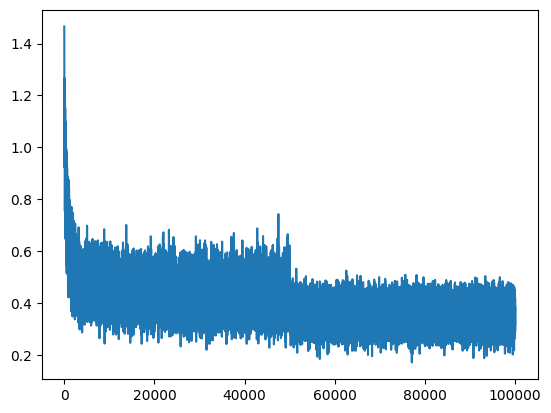

In [192]:
# plot to find optimal learning rate intuitively
plt.plot(stepi, lossi)

Loss is low since we're overfitting a single batch. Cannot have 0 loss as '...' has multiple labels

Using all words is too time-consuming, instead using mini batches

In [69]:
torch.randint(0, X.shape[0], (32,))

tensor([124204,  95714, 126590, 165403,   9048, 209688,  93939,  29160, 221601,
        116637, 224223,   6793,  81223,  71971,  48209, 189934, 180280,  28458,
        188380,  92106,   3046,  61885, 108105,  89164, 164592, 152254,  19035,
          5181, 132883, 210221, 196774, 113152])

This line is added in the mini-batch section of the code above

Gradient direction is not as reliable but this is much more time efficient.
To calculate the total loss after doing mini-batch training, do the same loss calculation but for all of X and Y

In [196]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 50) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

49.06958770751953

In [197]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, 50) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss.item()

49.077579498291016

Loss comes out to about 2.3, this is better than 2.45 with the bigram model.
However, loss shouldn't be too low as we don't want to overfit the entire training set.

As a result, we split our data into a train split, validation/dev split, and test split - 80%, 10%, 10%

After splitting, we still get a pretty similar (i.e., decent) loss. As the training and dev losses are roughly equal, it's likely we are underfitting, possibly because our hidden layer is too small.
We could instead change it from 100 to 300 and see the difference.

Doing just this I now get 2.264 on the dev set and 2.27 on the test set. Other bottlenecks include: embedding dimension, batch size, context length, learning rate, training time, weight decay, datset size, architecture of the MLP, activation function saturation, and more.

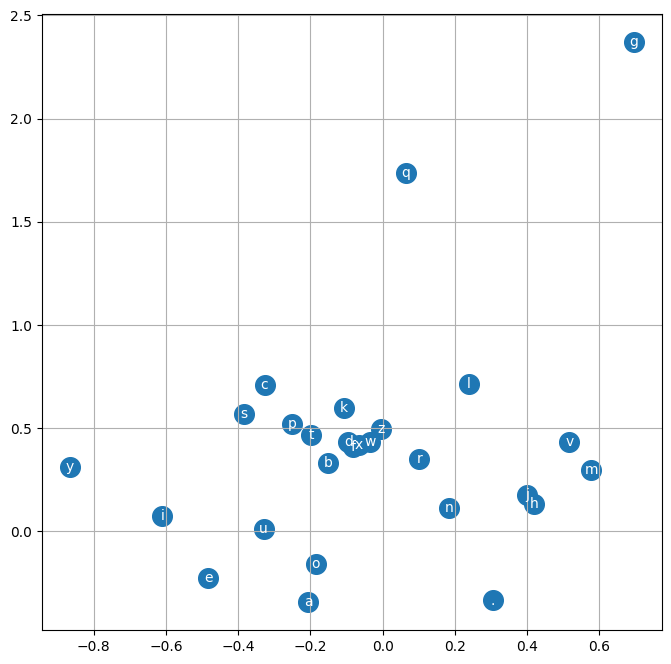

In [143]:
# Vizualization of the embedding vectors (when in 2-D)
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

After changing to 10-D embedding vectors, we get a loss of 2.20, another improvement. The reduction in the loss would suggest that the embedding dimension was a bottleneck.

When I change context size to 5 from 3, I get a dev loss of 2.213 and a test loss of 2.213. This shows that increasing the context size had little impact on my loss score, suggesting that context size is not *currently* the main limiting factor.